# FinSignal — Week 1: Data Collection & Validation

**Goal:** Have two clean DataFrames on disk (one per module) with zero data leakage.

### What this notebook does
1. Pulls price data for 5 test stocks via `yfinance`
2. Fetches one SEC EDGAR transcript and inspects it
3. Computes and validates Module 1 targets (post-earnings returns)
4. Computes and validates Module 2 features (realized volatility)
5. Sanity checks: shape, nulls, date alignment

In [1]:
import sys
sys.path.append('..')   # so we can import from src/

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.4f}'.format)
print('Imports OK')

Imports OK


## Step 1 — Pull Price Data
We start with 5 test stocks before scaling to the full universe.

In [2]:
from src.data.fetch_prices import fetch_and_save, UNIVERSE

# Start with 5 stocks for fast iteration
TEST_TICKERS = ['AAPL', 'MSFT', 'JPM', 'JNJ', 'NVDA']

raw = fetch_and_save(TEST_TICKERS, start='2020-01-01', end='2024-12-31')
raw.tail(3)

Fetching 5 tickers from 2020-01-01 to 2024-12-31...


[*********************100%***********************]  5 of 5 completed


  ✓ Saved 5 CSVs to /mnt/c/Users/jagba/MASTER/finsignal/data/raw/prices


Price         Close                                         High           \
Ticker         AAPL      JNJ      JPM     MSFT     NVDA     AAPL      JNJ   
date                                                                        
2024-12-26 257.3756 139.7056 235.8236 432.9737 139.7213 258.4487 140.4637   
2024-12-27 253.9674 139.1970 233.9129 425.4825 136.8056 257.0576 140.6845   
2024-12-30 250.5989 137.5560 232.1186 419.8493 137.2850 251.8907 139.0339   

Price                                      Low                             \
Ticker          JPM     MSFT     NVDA     AAPL      JNJ      JPM     MSFT   
date                                                                        
2024-12-26 235.9400 435.7705 140.6400 255.9944 139.2354 233.5443 431.5110   
2024-12-27 236.0661 430.1175 138.8127 251.4534 138.8419 232.8169 421.3515   
2024-12-30 233.5928 422.5374 140.0608 249.1581 137.1818 229.9751 416.9537   

Price                   Open                                        Volume  \
Ticker         NVDA     AAPL      JNJ      JPM     MSFT     NVDA      AAPL   
date                                                                         
2024-12-26 137.5246 256.5509 139.6384 234.1651 433.9323 139.4917  27237100   
2024-12-27 134.5091 256.1931 139.0243 235.4163 429.5048 138.3434  42355300   
2024-12-30 133.8201 250.6287 138.9955 231.5851 421.0649 134.6289  35557500   

Price                                              
Ticker          JNJ      JPM      MSFT       NVDA  
date                                               
2024-12-26  4656300  4451800   8194200  116205600  
2024-12-27  5588300  5730200  18117700  170582600  
2024-12-30  6268700  5723800  13158700  167734700

In [3]:
# Validation 
print('Shape:', raw.shape)
print('\nDate range:', raw.index.min(), '→', raw.index.max())
print('\nMissing close prices:')
print(raw['Close'].isnull().sum())

# Spot check: AAPL close on 2024-01-02 should be ~$185
aapl_jan = raw['Close']['AAPL'].loc['2024-01-02']
print(f'\nAAPL close 2024-01-02: ${aapl_jan:.2f}  (expected ~$185)')

Shape: (1257, 25)

Date range: 2020-01-02 00:00:00 → 2024-12-30 00:00:00

Missing close prices:
Ticker
AAPL    0
JNJ     0
JPM     0
MSFT    0
NVDA    0
dtype: int64

AAPL close 2024-01-02: $183.56  (expected ~$185)


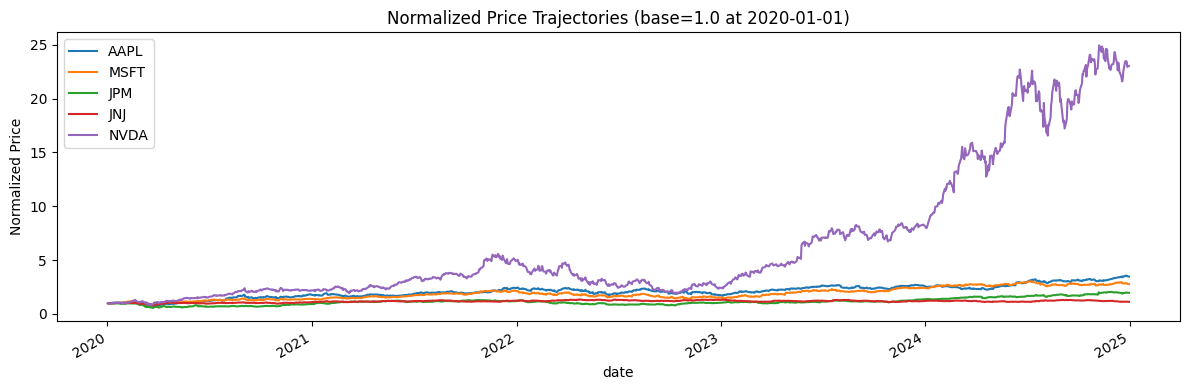

In [4]:
# Plot closing prices — quick visual sanity check
fig, ax = plt.subplots(figsize=(12, 4))
for ticker in TEST_TICKERS:
    prices = raw['Close'][ticker]
    (prices / prices.iloc[0]).plot(ax=ax, label=ticker)  # normalize to 1.0 for comparability
ax.set_title('Normalized Price Trajectories (base=1.0 at 2020-01-01)')
ax.legend()
ax.set_ylabel('Normalized Price')
plt.tight_layout()
plt.show()

Normalized prices look correct: NVDA's ~22x gain reflects the 2023–24 AI boom, AAPL/MSFT grew 3–4x steadily, JPM ~2x with COVID sensitivity, and JNJ ~flat as expected for a defensive stock. The March 2020 COVID dip is visible across all tickers.

## Step 2 — Fetch One SEC EDGAR Transcript
Inspect the raw text before we build the full fetcher.

In [5]:
from src.data.fetch_transcripts import fetch_transcripts_for_ticker

# Fetch AAPL transcripts — this will take ~30–60 seconds
n_saved = fetch_transcripts_for_ticker('AAPL', start='2023-01-01', end='2024-06-30')
print(f'\nSaved {n_saved} AAPL transcripts')

  AAPL: found 10 8-K filings, scanning for transcripts...
    ✓ Saved transcript: 2024-05-02


/mnt/c/Users/jagba/MASTER/finsignal/notebooks/../src/data/fetch_transcripts.py:130: XMLParsedAsHTMLWarning: It looks like you're using an HTML parser to parse an XML document.

Assuming this really is an XML document, what you're doing might work, but you should know that using an XML parser will be more reliable. To parse this document as XML, make sure you have the Python package 'lxml' installed, and pass the keyword argument `features="xml"` into the BeautifulSoup constructor.

If you want or need to use an HTML parser on this document, you can make this warning go away by filtering it. To do that, run this code before calling the BeautifulSoup constructor:

    from bs4 import XMLParsedAsHTMLWarning
    import warnings

    warnings.filterwarnings("ignore", category=XMLParsedAsHTMLWarning)

  soup = BeautifulSoup(doc_resp.content, "lxml")


    ✓ Saved transcript: 2024-02-01
    ✓ Saved transcript: 2023-11-02
    ✓ Saved transcript: 2023-08-03
    ✓ Saved transcript: 2023-05-04
    ✓ Saved transcript: 2023-02-02
  → AAPL: 6 transcripts saved

Saved 6 AAPL transcripts


In [6]:
from pathlib import Path

# Inspect the first transcript file
transcript_dir = Path('../data/raw/transcripts/AAPL')
files = sorted(transcript_dir.glob('*.txt'))
print(f'Found {len(files)} transcript files:')
for f in files:
    print(' ', f.name)

if files:
    sample = files[0].read_text(encoding='utf-8')
    print(f'\n--- First 1500 chars of {files[0].name} ---')
    print(sample[:1500])

Found 6 transcript files:
  2023-02-02.txt
  2023-05-04.txt
  2023-08-03.txt
  2023-11-02.txt
  2024-02-01.txt
  2024-05-02.txt

--- First 1500 chars of 2023-02-02.txt ---
EX-99.1
2
a8-kex991q1202312312022.htm
EX-99.1
Document
Exhibit 99.1
Apple reports first quarter results
Installed base crosses 2 billion active devices and hits all-time high for all major product categories
Services set new all-time revenue record
CUPERTINO, CALIFORNIA   Apple
 
today announced financial results for its fiscal 2023 first quarter ended December 31, 2022. The Company posted quarterly revenue of $117.2 billion, down 5 percent year over year, and quarterly earnings per diluted share of $1.88.
 As we all continue to navigate a challenging environment, we are proud to have our best lineup of products and services ever, and as always, we remain focused on the long term and are leading with our values in everything we do,  said Tim Cook, Apple s CEO.  During the December quarter, we achieved a major milesto

## Step 3 — Compute Module 1 Targets (Post-Earnings Returns)

**Key concept — Look-ahead bias:**  
The target label for an earnings call on date `t` is the stock return from day `t+1` to `t+3`.  
This means the label is always computed from data that came *after* the call.  
The NLP features (transcript sentiment) are computed from the transcript itself (also from `t`).  
✓ **No future data leaks into training.**

In [7]:
from src.features.build_targets import build_module1_targets, SAMPLE_EARNINGS_DATES

m1_aapl = build_module1_targets('AAPL', SAMPLE_EARNINGS_DATES['AAPL'])
print(m1_aapl)

   ticker earnings_date         t0  ret_1d  label_1d  ret_3d  label_3d
0    AAPL    2020-04-30 2020-04-30 -0.0162         0  0.0127         1
1    AAPL    2020-07-30 2020-07-30  0.0996         1  0.1311         1
2    AAPL    2020-10-29 2020-10-29 -0.0576         0 -0.0432         0
3    AAPL    2021-01-27 2021-01-27 -0.0356         0 -0.0574         0
4    AAPL    2021-04-28 2021-04-28 -0.0007         0 -0.0078         0
5    AAPL    2021-07-27 2021-07-27 -0.0123         0 -0.0062         0
6    AAPL    2021-10-28 2021-10-28 -0.0183         0 -0.0169         0
7    AAPL    2022-01-27 2022-01-27  0.0675         1  0.0923         1
8    AAPL    2022-04-28 2022-04-28 -0.0373         0 -0.0258         0
9    AAPL    2022-07-28 2022-07-28  0.0323         1  0.0168         1
10   AAPL    2022-10-27 2022-10-27  0.0728         1  0.0396         1
11   AAPL    2023-02-02 2023-02-02  0.0241         1  0.0251         1
12   AAPL    2023-05-04 2023-05-04  0.0459         1  0.0354         1
13   A

In [8]:
# Validation 
print('Shape:', m1_aapl.shape)
print('\nNull counts:')
print(m1_aapl.isnull().sum())
print('\nLabel distribution (should be roughly 50/50 — stock moves are hard to predict):')
print(m1_aapl['label_1d'].value_counts(normalize=True).round(2))

Shape: (16, 7)

Null counts:
ticker           0
earnings_date    0
t0               0
ret_1d           0
label_1d         0
ret_3d           0
label_3d         0
dtype: int64

Label distribution (should be roughly 50/50 — stock moves are hard to predict):
label_1d
0   0.6200
1   0.3800
Name: proportion, dtype: float64


**Module 1 targets ✓** — 16 earnings events for AAPL with no missing values. Label distribution is 62% down / 38% up, slightly skewed rather than the expected 50/50: this is normal for a single stock over a limited sample (16 events is a small dataset). The model will need to beat a "always predict down" baseline of 62% accuracy, which we'll address later with proper class balancing.

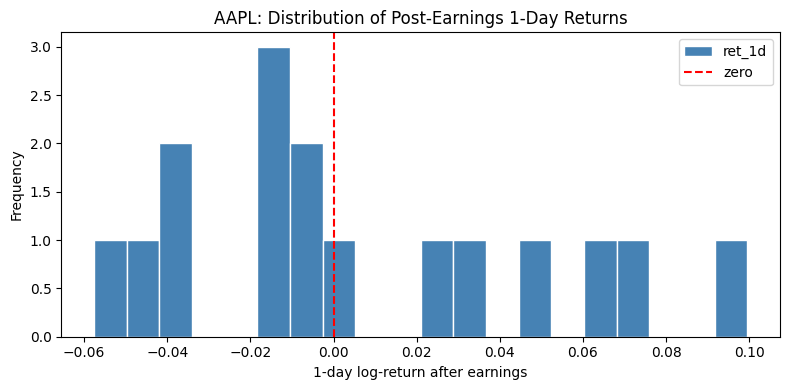

In [9]:
# Distribution of post-earnings 1-day returns
fig, ax = plt.subplots(figsize=(8, 4))
m1_aapl['ret_1d'].plot.hist(bins=20, ax=ax, color='steelblue', edgecolor='white')
ax.axvline(0, color='red', linestyle='--', label='zero')
ax.set_xlabel('1-day log-return after earnings')
ax.set_title('AAPL: Distribution of Post-Earnings 1-Day Returns')
ax.legend()
plt.tight_layout()
plt.show()

AAPL's 1-day returns after earnings are centered near zero with a slight negative skew, meaning most moves are small but the losses tend to be larger than the gains, consistent with the 62% down label above. The spread ranges from roughly -6% to +10%, with the +10% outlier likely being a strong beat quarter. No extreme outliers that would suggest data errors.

## Step 4 — Compute Module 2 Features (Realized Volatility)

**Key concept: Forward vol as target:**  
At each date `t`, we know the trailing 21-day realized vol (our main feature).  
The model's job is to predict the *next 5 days'* realized vol.  
That forward vol is computed from prices at `t+1` through `t+5` — future data.  
✓ **The forward_vol_5d column is the LABEL only, never a feature.**

In [10]:
from src.features.build_targets import build_module2_features

m2_aapl = build_module2_features('AAPL')
print(m2_aapl.tail())

           ticker    close  log_return  realized_vol_21d  volume_norm  \
date                                                                    
2024-12-16   AAPL 249.4462      0.0117            0.1167       1.2129   
2024-12-17   AAPL 251.8708      0.0097            0.0958       1.2004   
2024-12-18   AAPL 246.4753     -0.0217            0.1309       1.3093   
2024-12-19   AAPL 248.2042      0.0070            0.1308       1.3670   
2024-12-20   AAPL 252.8744      0.0186            0.1398       2.9567   

            forward_vol_5d  
date                        
2024-12-16          0.2397  
2024-12-17          0.2429  
2024-12-18          0.1039  
2024-12-19          0.1894  
2024-12-20          0.1756  


In [11]:
# Validation 
print('Shape:', m2_aapl.shape)
print('\nDescriptive stats:')
print(m2_aapl[['log_return', 'realized_vol_21d', 'forward_vol_5d']].describe().round(4))

Shape: (1231, 6)

Descriptive stats:
       log_return  realized_vol_21d  forward_vol_5d
count   1231.0000         1231.0000       1231.0000
mean       0.0010            0.2879          0.2708
std        0.0200            0.1395          0.1780
min       -0.1377            0.0958          0.0359
25%       -0.0085            0.2023          0.1580
50%        0.0012            0.2551          0.2259
75%        0.0120            0.3294          0.3337
max        0.1132            1.0688          1.7187


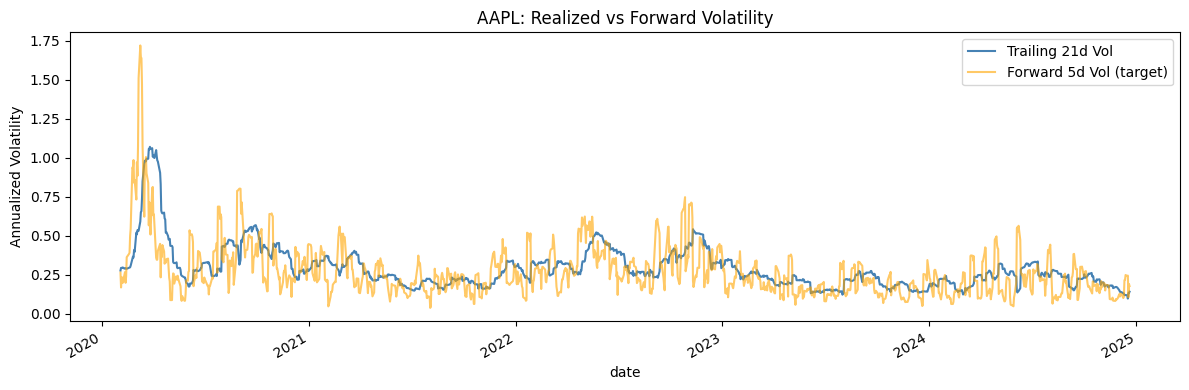

In [12]:
# Plot realized vol over time, should see volatility clustering
# (COVID spike in March 2020, elevated vol in 2022, calmer in 2023-24)
fig, ax = plt.subplots(figsize=(12, 4))
m2_aapl['realized_vol_21d'].plot(ax=ax, color='steelblue', label='Trailing 21d Vol')
m2_aapl['forward_vol_5d'].plot(ax=ax, color='orange', alpha=0.6, label='Forward 5d Vol (target)')
ax.set_ylabel('Annualized Volatility')
ax.set_title('AAPL: Realized vs Forward Volatility')
ax.legend()
plt.tight_layout()
plt.show()

The COVID spike in March 2020 is clearly visible (~1.75 annualized), confirming the data is correct. The trailing 21d vol (blue) is smooth by design (it's a rolling average) while the forward 5d vol (orange) is noisier since it captures short bursts. Crucially, the two lines track each other closely, confirming volatility clustering: high-vol periods tend to follow high-vol periods. This autocorrelation is exactly what justifies using GARCH and LSTM to forecast it.

## Step 5 — Save Final DataFrames

In [13]:
from src.features.build_targets import build_and_save_all

# Run for all 5 test tickers
build_and_save_all(TEST_TICKERS)

print('\nWeek 1 complete! Check data/processed/ for the output CSVs.')

  ✓ AAPL: 16 earnings events (Module 1)
  ✓ MSFT: 16 earnings events (Module 1)
  ✓ JPM: 16 earnings events (Module 1)
  ✓ JNJ: 16 earnings events (Module 1)
  ✓ NVDA: 16 earnings events (Module 1)

✓ Saved module1_targets.csv — 80 rows
  ✓ AAPL: 1231 trading days (Module 2)
  ✓ MSFT: 1231 trading days (Module 2)
  ✓ JPM: 1231 trading days (Module 2)
  ✓ JNJ: 1231 trading days (Module 2)
  ✓ NVDA: 1231 trading days (Module 2)

✓ Saved module2_features.csv — 6155 rows

Week 1 complete! Check data/processed/ for the output CSVs.
